In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# Initialize SHAP's JavaScript visualizations
shap.initjs()

print("SHAP version:", shap.__version__)
print("Ready!")

SHAP version: 0.51.0
Ready!


In [12]:
# Load the best model for Fraud_Data → LightGBM
lgb_model = joblib.load('../models/lightgbm_fraud.pkl')

# Load test data
X_test = pd.read_csv('../data/processed/X_test_fraud.csv')
y_test = pd.read_csv('../data/processed/y_test_fraud.csv').squeeze()

# Load feature names
feature_names = joblib.load('../models/feature_names_fraud.pkl')
X_test.columns = feature_names

print(f"X_test shape: {X_test.shape}")
print(f"Model loaded: LightGBM")

# Get model predictions — we need these to find TP, FP, FN examples
y_pred  = lgb_model.predict(X_test)
y_proba = lgb_model.predict_proba(X_test)[:, 1]

print(f"\nPrediction summary:")
print(f"  Predicted fraud:  {y_pred.sum()}")
print(f"  Actual fraud:     {y_test.sum()}")

X_test shape: (30223, 198)
Model loaded: LightGBM

Prediction summary:
  Predicted fraud:  1495
  Actual fraud:     2830


In [13]:
# Create the SHAP explainer
# TreeExplainer is optimized for tree-based models like LightGBM/XGBoost
print("Computing SHAP values... (may take 1-2 minutes)")

explainer = shap.TreeExplainer(lgb_model)

# Compute SHAP values for the test set
# We use a sample of 2000 rows to keep it fast
# SHAP on all 30k rows would take too long
np.random.seed(42)
sample_idx = np.random.choice(len(X_test), size=2000, replace=False)
X_sample = X_test.iloc[sample_idx]

shap_values = explainer.shap_values(X_sample)

# For binary classification, LightGBM returns two arrays (one per class)
# We want class 1 (fraud)
if isinstance(shap_values, list):
    shap_fraud = shap_values[1]  # fraud class
else:
    shap_fraud = shap_values

print(f"SHAP values computed!")
print(f"Shape: {shap_fraud.shape}  (rows × features)")

Computing SHAP values... (may take 1-2 minutes)
SHAP values computed!
Shape: (2000, 198)  (rows × features)


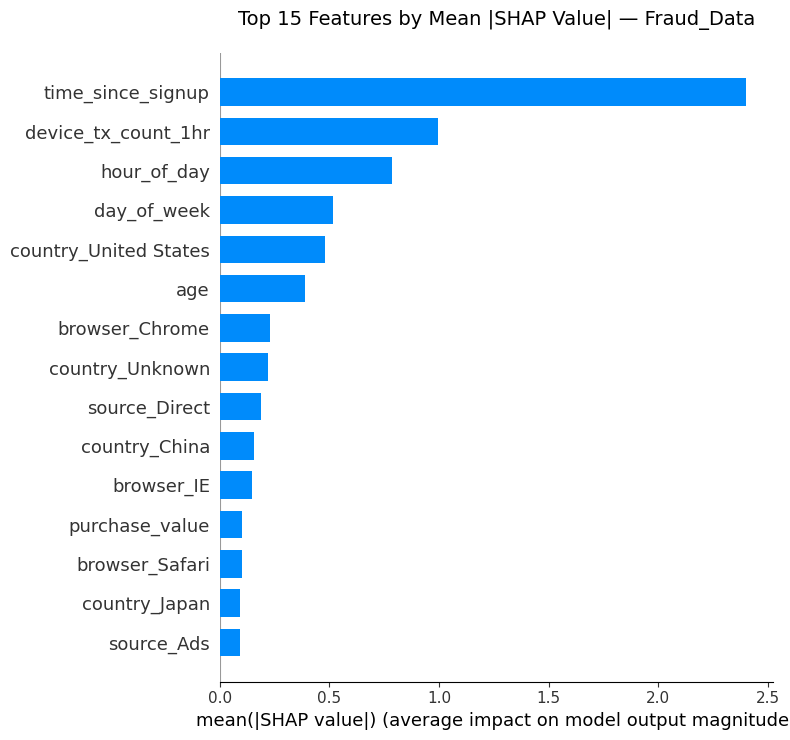

Bar plot saved!


In [14]:
# Simple bar chart — mean absolute SHAP value per feature
# "On average, how much does each feature move the prediction?"

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_fraud, 
    X_sample,
    plot_type="bar",
    max_display=15,        # show top 15 features
    show=False
)
plt.title("Top 15 Features by Mean |SHAP Value| — Fraud_Data", 
          fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('../models/shap_bar_fraud.png', dpi=150, bbox_inches='tight')
plt.show()
print("Bar plot saved!")

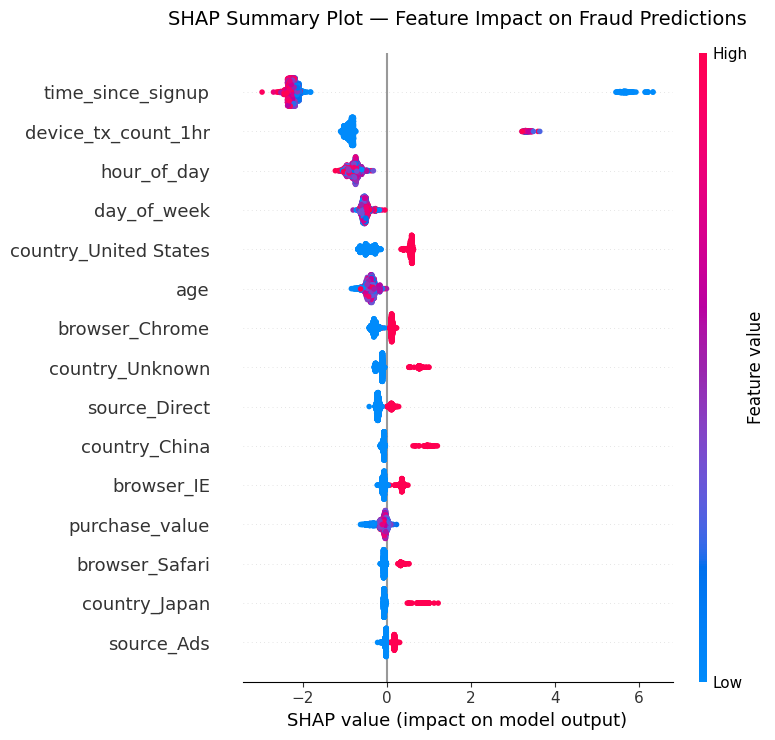

Summary plot saved!


In [15]:
# Beeswarm plot — shows BOTH importance AND direction
# Each dot = one transaction
# Color = feature value (red=high, blue=low)
# Position on x = SHAP impact (right=pushes toward fraud, left=toward legit)

plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_fraud,
    X_sample,
    max_display=15,
    show=False
)
plt.title("SHAP Summary Plot — Feature Impact on Fraud Predictions",
          fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('../models/shap_summary_fraud.png', dpi=150, bbox_inches='tight')
plt.show()
print("Summary plot saved!")

In [16]:
# We need specific examples:
# True Positive  (TP): actual fraud, correctly predicted fraud
# False Positive (FP): actual legit, wrongly predicted fraud  
# False Negative (FN): actual fraud, wrongly predicted legit

y_test_arr = y_test.values
y_pred_arr = y_pred

# Step 1: Build boolean masks
tp_mask = (y_test_arr == 1) & (y_pred_arr == 1)
fp_mask = (y_test_arr == 0) & (y_pred_arr == 1)
fn_mask = (y_test_arr == 1) & (y_pred_arr == 0)

# Step 2: Get indices
tp_indices = np.where(tp_mask)[0]
fp_indices = np.where(fp_mask)[0]
fn_indices = np.where(fn_mask)[0]

print(f"True Positives  available: {len(tp_indices)}")
print(f"False Positives available: {len(fp_indices)}")
print(f"False Negatives available: {len(fn_indices)}")

# Step 3: Pick best example of each — guard against empty arrays
tp_idx = tp_indices[np.argmax(y_proba[tp_indices])] if len(tp_indices) > 0 else None
fp_idx = fp_indices[np.argmax(y_proba[fp_indices])] if len(fp_indices) > 0 else None
fn_idx = fn_indices[np.argmin(y_proba[fn_indices])] if len(fn_indices) > 0 else None

print(f"\nSelected examples:")
print(f"  TP index: {tp_idx}  fraud probability: {y_proba[tp_idx]:.3f}" if tp_idx is not None else "  TP: none found")
print(f"  FP index: {fp_idx}  fraud probability: {y_proba[fp_idx]:.3f}" if fp_idx is not None else "  FP: none found (model had 0 false positives!)")
print(f"  FN index: {fn_idx}  fraud probability: {y_proba[fn_idx]:.3f}" if fn_idx is not None else "  FN: none found")

# Step 4: Collect only the valid indices for SHAP
example_indices = [i for i in [tp_idx, fp_idx, fn_idx] if i is not None]
example_labels  = [l for i, l in zip([tp_idx, fp_idx, fn_idx], ["TP", "FP", "FN"]) if i is not None]

X_examples = X_test.iloc[example_indices]
shap_examples = explainer.shap_values(X_examples)

if isinstance(shap_examples, list):
    shap_examples_fraud = shap_examples[1]
else:
    shap_examples_fraud = shap_examples

expected_value = explainer.expected_value
if isinstance(expected_value, list):
    expected_value = expected_value[1]

print(f"\nComputed SHAP values for: {example_labels}")


True Positives  available: 1495
False Positives available: 0
False Negatives available: 1335

Selected examples:
  TP index: 856  fraud probability: 1.000
  FP: none found (model had 0 false positives!)
  FN index: 24348  fraud probability: 0.016

Computed SHAP values for: ['TP', 'FN']



  True Positive  (Fraud Correctly Caught)
  Actual:            FRAUD
  Predicted:         FRAUD
  Fraud probability: 1.000

  Top 8 feature contributions:
  Feature                               Value       SHAP
  ------------------------------------------------------
  time_since_signup                    -1.576    +5.7605  → FRAUD
  device_tx_count_1hr                   5.696    +3.4317  → FRAUD
  country_India                         1.000    +0.6043  → FRAUD
  hour_of_day                          -1.521    -0.4085  → LEGIT
  age                                   0.914    -0.3794  → LEGIT
  country_United States                 0.000    -0.2018  → LEGIT
  browser_Chrome                        1.000    +0.1867  → FRAUD
  day_of_week                           1.489    -0.1708  → LEGIT


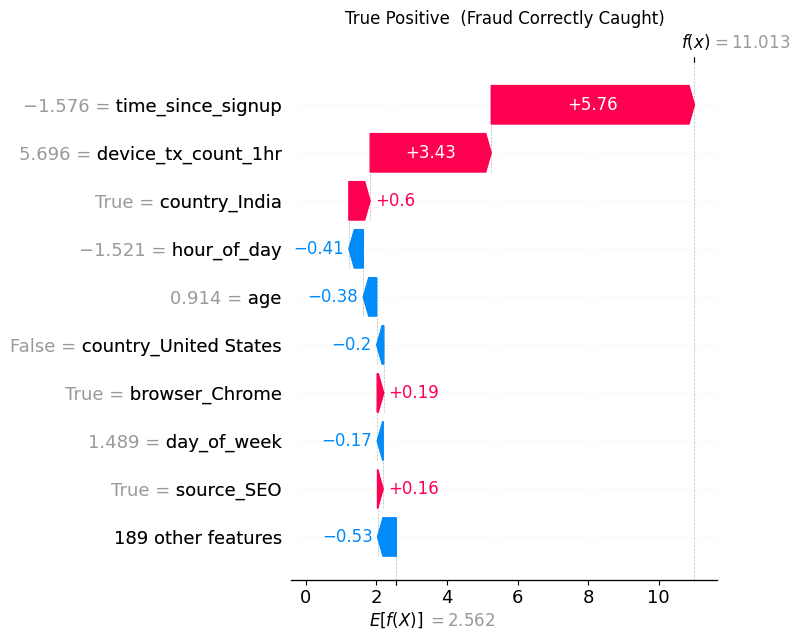


  False Negative (Fraud Incorrectly Missed)
  Actual:            FRAUD
  Predicted:         LEGIT
  Fraud probability: 0.016

  Top 8 feature contributions:
  Feature                               Value       SHAP
  ------------------------------------------------------
  time_since_signup                    -0.622    -2.3220  → LEGIT
  device_tx_count_1hr                  -0.185    -1.0062  → LEGIT
  hour_of_day                           1.659    -0.9576  → LEGIT
  age                                  -1.754    -0.7320  → LEGIT
  day_of_week                           1.489    -0.7076  → LEGIT
  browser_Safari                        1.000    +0.3988  → FRAUD
  browser_Chrome                        0.000    -0.3823  → LEGIT
  country_United States                 0.000    -0.2344  → LEGIT


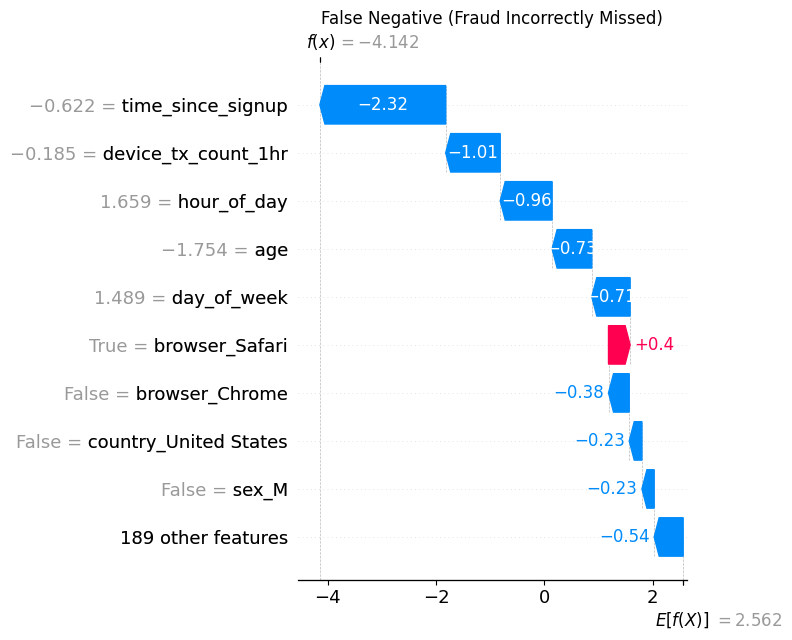

In [17]:
label_map = {
    "TP": "True Positive  (Fraud Correctly Caught)",
    "FP": "False Positive (Legit Wrongly Flagged)",
    "FN": "False Negative (Fraud Incorrectly Missed)"
}
file_map = {"TP": "tp", "FP": "fp", "FN": "fn"}

for i, (idx, short_label) in enumerate(zip(example_indices, example_labels)):
    label    = label_map[short_label]
    actual   = int(y_test_arr[idx])
    predicted = int(y_pred_arr[idx])
    proba    = float(y_proba[idx])

    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    print(f"  Actual:            {'FRAUD' if actual == 1 else 'LEGIT'}")
    print(f"  Predicted:         {'FRAUD' if predicted == 1 else 'LEGIT'}")
    print(f"  Fraud probability: {proba:.3f}")

    # Top contributing features for this prediction
    shap_row = shap_examples_fraud[i]
    top_idx  = np.argsort(np.abs(shap_row))[::-1][:8]

    print(f"\n  Top 8 feature contributions:")
    print(f"  {'Feature':<30} {'Value':>12} {'SHAP':>10}")
    print(f"  {'-'*54}")
    for j in top_idx:
        feat_val  = X_examples.iloc[i, j]
        shap_val  = shap_row[j]
        direction = "→ FRAUD" if shap_val > 0 else "→ LEGIT"
        print(f"  {feature_names[j]:<30} {feat_val:>12.3f} {shap_val:>+10.4f}  {direction}")

    # Waterfall plot
    fig, ax = plt.subplots(figsize=(14, 3))
    shap.plots.waterfall(
        shap.Explanation(
            values=shap_row,
            base_values=expected_value,
            data=X_examples.iloc[i].values,
            feature_names=feature_names
        ),
        max_display=10,
        show=False
    )
    plt.title(label, fontsize=12)
    plt.tight_layout()
    plt.savefig(f'../models/shap_force_{file_map[short_label]}_fraud.png',
                dpi=150, bbox_inches='tight')
    plt.show()


XGBoost False Positives found: 54
Selected FP index: 14080
Actual label:      0  (should be 0 = legit)
Predicted label:   1  (should be 1 = fraud)
Fraud probability: 0.852


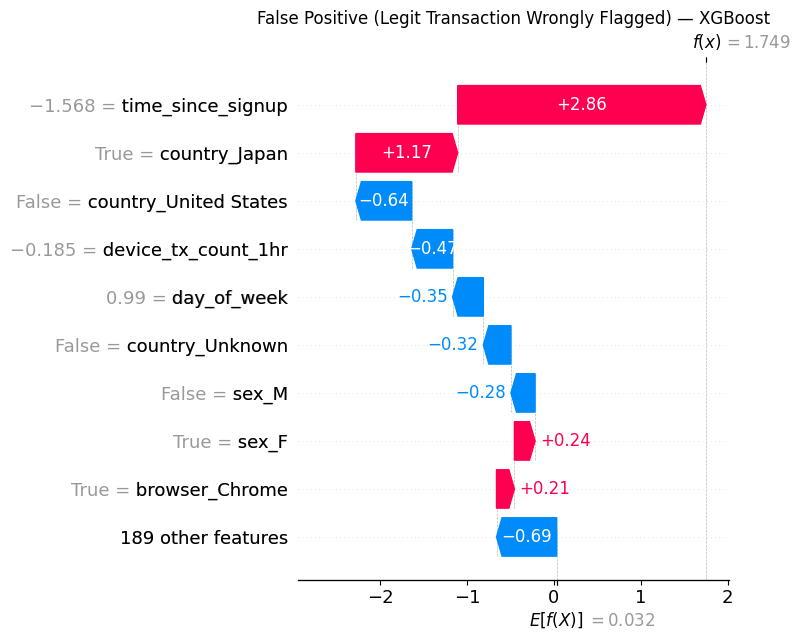

In [19]:
# LightGBM has zero FPs — use XGBoost for the FP example
xgb_model = joblib.load('../models/xgboost_fraud.pkl')

y_pred_xgb  = xgb_model.predict(X_test.values)
y_proba_xgb = xgb_model.predict_proba(X_test.values)[:, 1]

# Find FP in XGBoost predictions
fp_mask_xgb = (y_test_arr == 0) & (y_pred_xgb == 1)
fp_indices_xgb = np.where(fp_mask_xgb)[0]

print(f"XGBoost False Positives found: {len(fp_indices_xgb)}")

# Pick most confident FP
fp_idx_xgb = fp_indices_xgb[np.argmax(y_proba_xgb[fp_indices_xgb])]

print(f"Selected FP index: {fp_idx_xgb}")
print(f"Actual label:      {y_test_arr[fp_idx_xgb]}  (should be 0 = legit)")
print(f"Predicted label:   {y_pred_xgb[fp_idx_xgb]}  (should be 1 = fraud)")
print(f"Fraud probability: {y_proba_xgb[fp_idx_xgb]:.3f}")

# SHAP explainer for XGBoost
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_fp = explainer_xgb.shap_values(X_test.iloc[[fp_idx_xgb]])

if isinstance(shap_fp, list):
    shap_fp_fraud = shap_fp[1][0]
else:
    shap_fp_fraud = shap_fp[0]

expected_value_xgb = explainer_xgb.expected_value
if isinstance(expected_value_xgb, list):
    expected_value_xgb = expected_value_xgb[1]

# Plot
shap.plots.waterfall(
    shap.Explanation(
        values=shap_fp_fraud,
        base_values=expected_value_xgb,
        data=X_test.iloc[fp_idx_xgb].values,
        feature_names=feature_names
    ),
    max_display=10,
    show=False
)
plt.title("False Positive (Legit Transaction Wrongly Flagged) — XGBoost", fontsize=12)
plt.tight_layout()
plt.savefig('../models/shap_force_fp_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# ── creditcard.csv SHAP ──────────────────────────────────────────────
xgb_cc = joblib.load('../models/xgboost_creditcard.pkl')
feature_names_cc = joblib.load('../models/feature_names_creditcard.pkl')

X_test_cc = pd.read_csv('../data/processed/X_test_creditcard.csv')
y_test_cc = pd.read_csv('../data/processed/y_test_creditcard.csv').squeeze()
X_test_cc.columns = feature_names_cc

y_pred_cc  = xgb_cc.predict(X_test_cc.values)
y_proba_cc = xgb_cc.predict_proba(X_test_cc.values)[:, 1]

print(f"X_test_cc shape: {X_test_cc.shape}")
print(f"Fraud cases in test: {y_test_cc.sum()}")
print(f"Fraud caught: {((y_pred_cc==1) & (y_test_cc==1)).sum()}")
print(f"Fraud missed: {((y_pred_cc==0) & (y_test_cc==1)).sum()}")

X_test_cc shape: (56962, 30)
Fraud cases in test: 98
Fraud caught: 87
Fraud missed: 11


In [21]:
print("Computing SHAP values for creditcard XGBoost...")

explainer_cc = shap.TreeExplainer(xgb_cc)

# Sample 2000 rows
np.random.seed(42)
sample_idx_cc = np.random.choice(len(X_test_cc), size=2000, replace=False)
X_sample_cc = X_test_cc.iloc[sample_idx_cc]

shap_values_cc = explainer_cc.shap_values(X_sample_cc.values)
if isinstance(shap_values_cc, list):
    shap_fraud_cc = shap_values_cc[1]
else:
    shap_fraud_cc = shap_values_cc

print(f"SHAP values shape: {shap_fraud_cc.shape}")
print("Done!")

Computing SHAP values for creditcard XGBoost...
SHAP values shape: (2000, 30)
Done!


TP: 87, FP: 31, FN: 11


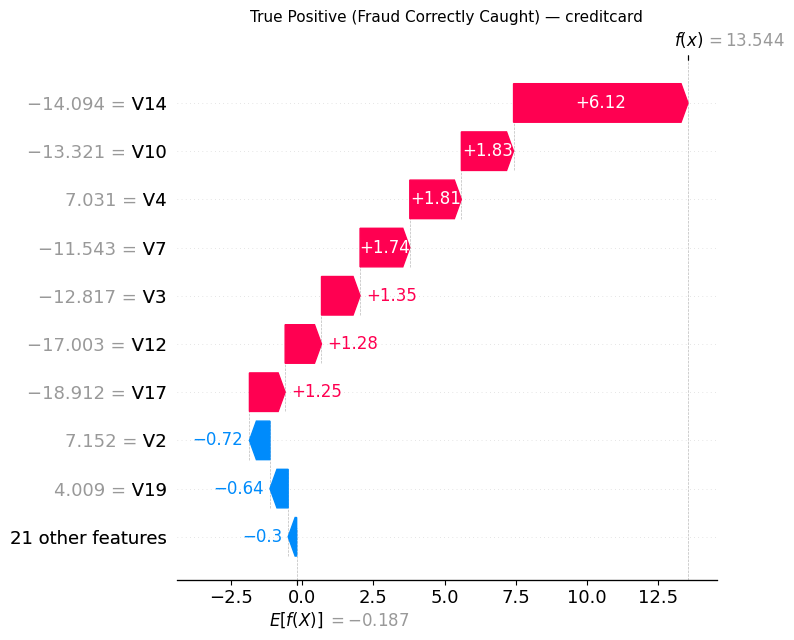

✅ TP plot saved


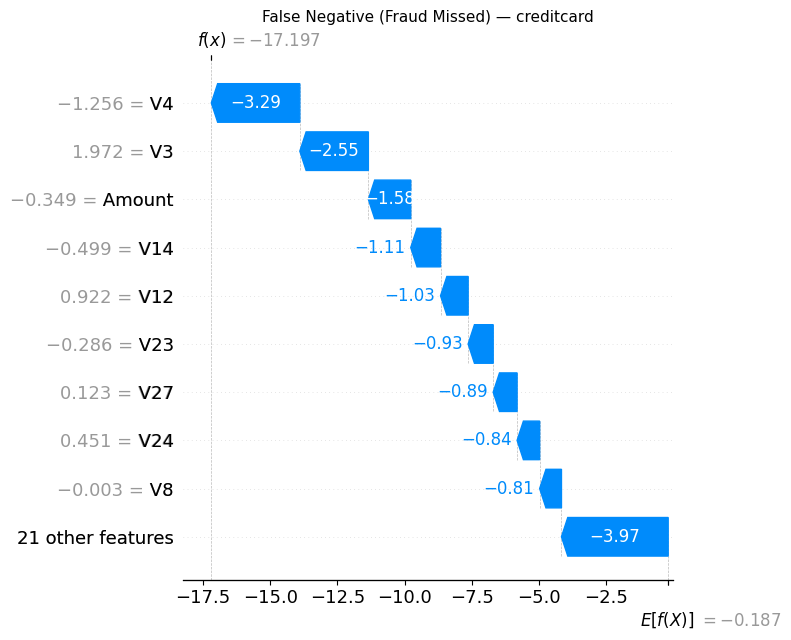

✅ FN plot saved


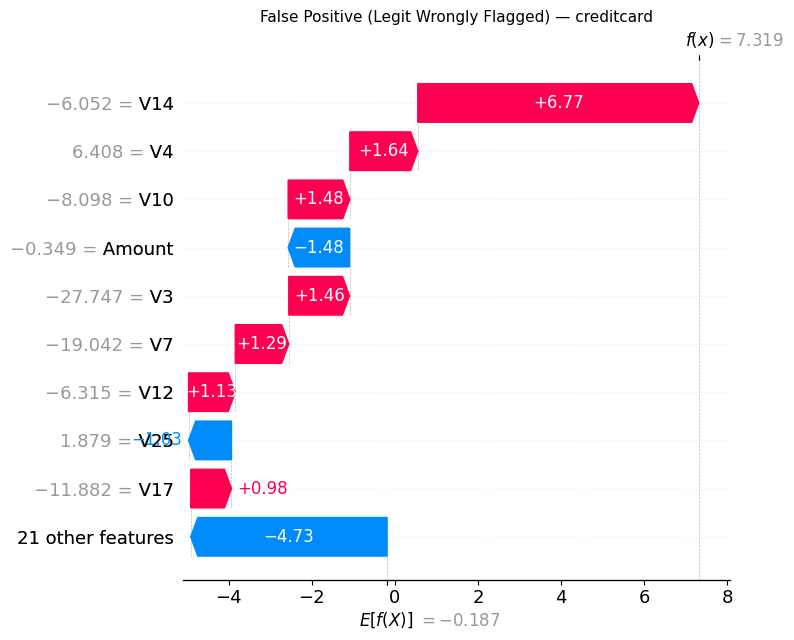

✅ FP plot saved


In [22]:
y_test_cc_arr = y_test_cc.values

# Find TP, FP, FN
tp_mask_cc = (y_test_cc_arr == 1) & (y_pred_cc == 1)
fp_mask_cc = (y_test_cc_arr == 0) & (y_pred_cc == 1)
fn_mask_cc = (y_test_cc_arr == 1) & (y_pred_cc == 0)

tp_idx_cc = np.where(tp_mask_cc)[0]
fp_idx_cc = np.where(fp_mask_cc)[0]
fn_idx_cc = np.where(fn_mask_cc)[0]

print(f"TP: {len(tp_idx_cc)}, FP: {len(fp_idx_cc)}, FN: {len(fn_idx_cc)}")

# Pick examples
tp_i = tp_idx_cc[np.argmax(y_proba_cc[tp_idx_cc])]
fp_i = fp_idx_cc[np.argmax(y_proba_cc[fp_idx_cc])] if len(fp_idx_cc) > 0 else None
fn_i = fn_idx_cc[np.argmin(y_proba_cc[fn_idx_cc])]

expected_cc = explainer_cc.expected_value
if isinstance(expected_cc, list):
    expected_cc = expected_cc[1]

examples = {'tp': tp_i, 'fn': fn_i}
if fp_i is not None:
    examples['fp'] = fp_i

titles = {
    'tp': 'True Positive (Fraud Correctly Caught) — creditcard',
    'fp': 'False Positive (Legit Wrongly Flagged) — creditcard',
    'fn': 'False Negative (Fraud Missed) — creditcard'
}

for label, idx in examples.items():
    shap_row = explainer_cc.shap_values(X_test_cc.iloc[[idx]].values)
    if isinstance(shap_row, list):
        shap_row = shap_row[1][0]
    else:
        shap_row = shap_row[0]

    shap.plots.waterfall(
        shap.Explanation(
            values=shap_row,
            base_values=expected_cc,
            data=X_test_cc.iloc[idx].values,
            feature_names=feature_names_cc
        ),
        max_display=10,
        show=False
    )
    plt.title(titles[label], fontsize=11)
    plt.tight_layout()
    plt.savefig(f'../models/shap_force_{label}_creditcard.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ {label.upper()} plot saved")

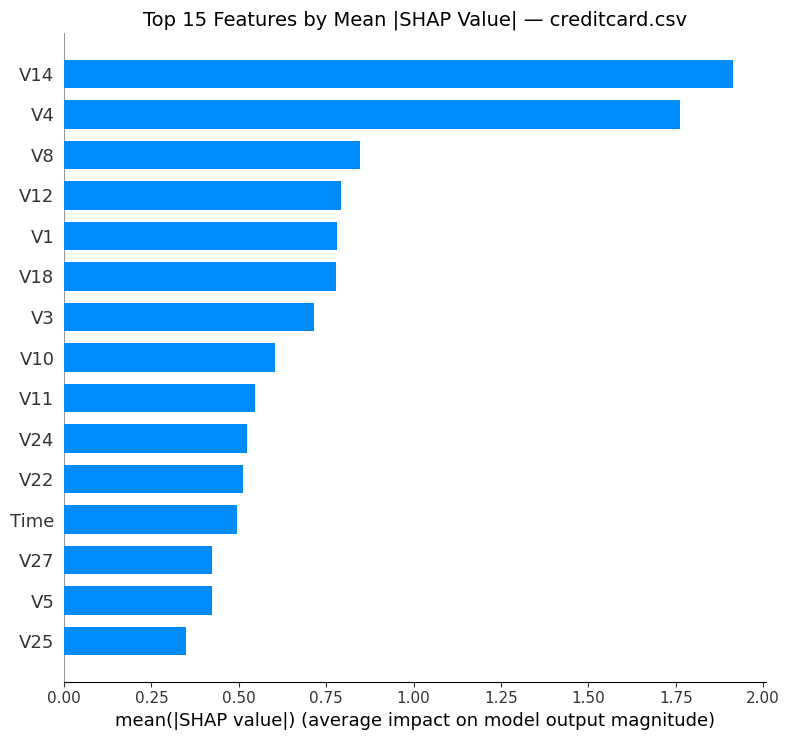

Bar plot done!


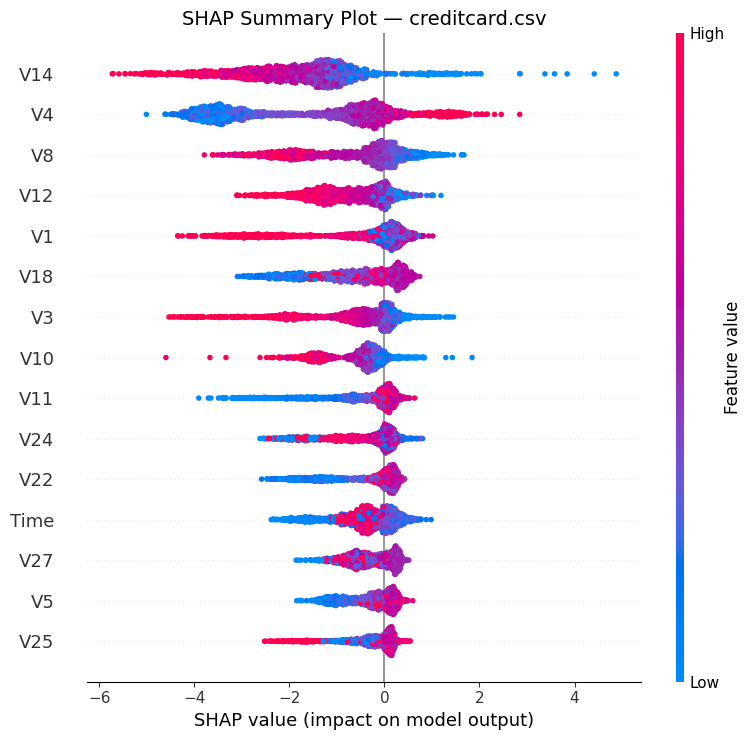

Summary plot done!


In [23]:
# Regenerate creditcard bar and summary plots
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_fraud_cc,
    X_sample_cc,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title("Top 15 Features by Mean |SHAP Value| — creditcard.csv", fontsize=14)
plt.tight_layout()
plt.savefig('../models/shap_bar_creditcard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Bar plot done!")

plt.figure(figsize=(12, 9))
shap.summary_plot(
    shap_fraud_cc,
    X_sample_cc,
    max_display=15,
    show=False
)
plt.title("SHAP Summary Plot — creditcard.csv", fontsize=14)
plt.tight_layout()
plt.savefig('../models/shap_summary_creditcard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Summary plot done!")